In [43]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from tensorflow import keras
from tensorflow.keras.layers import Input, Dense, LeakyReLU, Flatten, BatchNormalization
from tensorflow.keras.models import Model, Sequential, model_from_json
from tensorflow.keras.optimizers import SGD
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

import matplotlib.pyplot as plt
import seaborn as sns
import pickle


In [21]:
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

In [35]:
nsamples, nx, ny = x_train.shape
x_train_d2 = x_train.reshape((nsamples, nx * ny))
x_train_normed = StandardScaler().fit_transform(x_train_d2)

nsamples, nx, ny = x_test.shape
x_test_d2 = x_test.reshape((nsamples, nx * ny))
x_test_normed = StandardScaler().fit_transform(x_test_d2)

In [51]:
y_train_ohe = pd.get_dummies(y_train).as_matrix()
y_test_ohe = pd.get_dummies(y_test).as_matrix()

Baseline model

In [53]:
model_sequences = [
    keras.layers.Dense(units=32, activation='relu', input_shape=x_train_normed.shape[1:]),
    keras.layers.Dense(units=32, activation='relu', input_shape=x_train_normed.shape[1:]),
]

model_sequences.append(Dense(units=10, name='output', activation='softmax'))
nn_model = keras.models.Sequential(model_sequences)
print(nn_model.summary())

_________________________________________________________________
Layer (type)                 Output Shape              Param #   
dense_4 (Dense)              (None, 32)                25120     
_________________________________________________________________
dense_5 (Dense)              (None, 32)                1056      
_________________________________________________________________
output (Dense)               (None, 10)                330       
Total params: 26,506
Trainable params: 26,506
Non-trainable params: 0
_________________________________________________________________
None


Train on 60000 samples, validate on 10000 samples
Epoch 1/20
60000/60000 [==============================] - 3s 46us/step - loss: 0.7474 - acc: 0.7875 - val_loss: 0.3449 - val_acc: 0.9005
Epoch 2/20
60000/60000 [==============================] - 2s 34us/step - loss: 0.3018 - acc: 0.9123 - val_loss: 0.2652 - val_acc: 0.9236
Epoch 3/20
60000/60000 [==============================] - 2s 34us/step - loss: 0.2428 - acc: 0.9281 - val_loss: 0.2324 - val_acc: 0.9327
Epoch 4/20
60000/60000 [==============================] - 2s 34us/step - loss: 0.2112 - acc: 0.9377 - val_loss: 0.2118 - val_acc: 0.9371
Epoch 5/20
60000/60000 [==============================] - 2s 35us/step - loss: 0.1897 - acc: 0.9438 - val_loss: 0.1977 - val_acc: 0.9414
Epoch 6/20
60000/60000 [==============================] - 2s 35us/step - loss: 0.1737 - acc: 0.9483 - val_loss: 0.1879 - val_acc: 0.9451
Epoch 7/20
60000/60000 [==============================] - 2s 35us/step - loss: 0.1607 - acc: 0.9523 - val_loss: 0.1789 - val_acc

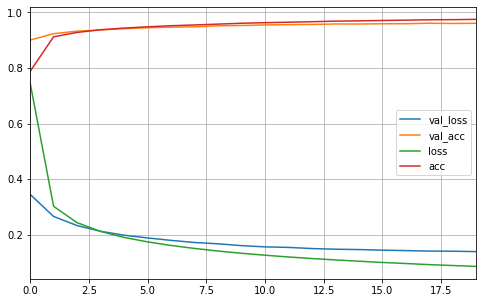

CPU times: user 1min 4s, sys: 8.84 s, total: 1min 13s
Wall time: 45.8 s


In [54]:
%%time
nn_model.compile(optimizer='sgd', loss='categorical_crossentropy', metrics=['accuracy'])
history = nn_model.fit(x_train_normed, y_train_ohe, validation_data=(x_test_normed, y_test_ohe), epochs=20, batch_size=64, verbose=1)
pd.DataFrame(history.history).plot(figsize=(8, 5))
plt.grid(True)
plt.show()

In [44]:
def save_keras_model(model, history, file_name):
    model_json = model.to_json()
    with open("./models/{}.json".format(file_name), 'w') as json_file:
        json_file.write(model_json)
    model.save_weights("./models/{}.h5".format(file_name))
    with open('./models/{}.history'.format(file_name), 'wb') as file_history:
        pickle.dump(history.history, file_history)
    print("model saved")
save_keras_model(nn_model, history, 'base_model')

model saved


Model with 64 neurons

In [56]:
model_sequences = [
    keras.layers.Dense(units=64, activation='relu', input_shape=x_train_normed.shape[1:]),
    keras.layers.Dense(units=64, activation='relu', input_shape=x_train_normed.shape[1:]),
]

model_sequences.append(Dense(units=10, name='output', activation='softmax'))
nn_model_64 = keras.models.Sequential(model_sequences)
print(nn_model_64.summary())

_________________________________________________________________
Layer (type)                 Output Shape              Param #   
dense_8 (Dense)              (None, 64)                50240     
_________________________________________________________________
dense_9 (Dense)              (None, 64)                4160      
_________________________________________________________________
output (Dense)               (None, 10)                650       
Total params: 55,050
Trainable params: 55,050
Non-trainable params: 0
_________________________________________________________________
None


Train on 60000 samples, validate on 10000 samples
Epoch 1/20
60000/60000 [==============================] - 3s 48us/step - loss: 0.6951 - acc: 0.8049 - val_loss: 0.3200 - val_acc: 0.9080
Epoch 2/20
60000/60000 [==============================] - 3s 46us/step - loss: 0.2761 - acc: 0.9201 - val_loss: 0.2384 - val_acc: 0.9303
Epoch 3/20
60000/60000 [==============================] - 2s 40us/step - loss: 0.2137 - acc: 0.9373 - val_loss: 0.2054 - val_acc: 0.9400
Epoch 4/20
60000/60000 [==============================] - 2s 40us/step - loss: 0.1814 - acc: 0.9468 - val_loss: 0.1847 - val_acc: 0.9457
Epoch 5/20
60000/60000 [==============================] - 2s 41us/step - loss: 0.1599 - acc: 0.9533 - val_loss: 0.1719 - val_acc: 0.9508
Epoch 6/20
60000/60000 [==============================] - 3s 43us/step - loss: 0.1433 - acc: 0.9586 - val_loss: 0.1608 - val_acc: 0.9534
Epoch 7/20
60000/60000 [==============================] - 3s 45us/step - loss: 0.1306 - acc: 0.9625 - val_loss: 0.1511 - val_acc

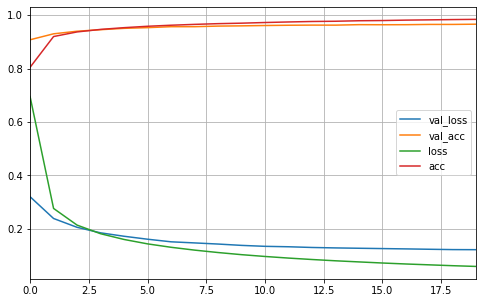

CPU times: user 1min 18s, sys: 9.87 s, total: 1min 28s
Wall time: 53.5 s


In [57]:
%%time
nn_model_64.compile(optimizer='sgd', loss='categorical_crossentropy', metrics=['accuracy'])
history = nn_model_64.fit(x_train_normed, y_train_ohe, validation_data=(x_test_normed, y_test_ohe), epochs=20, batch_size=64, verbose=1)
pd.DataFrame(history.history).plot(figsize=(8, 5))
plt.grid(True)
plt.show()